In [17]:
from pathlib import Path

# 🔧 Put the SAME BASE_DIR you used before
BASE_DIR = Path(r"DL_Assignment1_Dataset")  # <-- update
IMG_DIR  = BASE_DIR / "Dataset" / "Dataset" / "images"
ANNO_DIR = BASE_DIR / "Dataset" / "Dataset" / "annotations"

print("BASE_DIR exists:", BASE_DIR.exists())
print("IMG_DIR exists :", IMG_DIR.exists(), "|", IMG_DIR)
print("ANNO_DIR exists:", ANNO_DIR.exists(), "|", ANNO_DIR)

img_cnt = sum(1 for _ in IMG_DIR.rglob("*") if _.suffix.lower() in {".jpg",".jpeg",".png"})
anno_cnt = sum(1 for _ in ANNO_DIR.glob("*.npy")) + sum(1 for _ in ANNO_DIR.glob("*.npz"))
print("Image files:", img_cnt)
print("Annotation npy/npz files:", anno_cnt)


BASE_DIR exists: True
IMG_DIR exists : True | DL_Assignment1_Dataset\Dataset\Dataset\images
ANNO_DIR exists: True | DL_Assignment1_Dataset\Dataset\Dataset\annotations
Image files: 3999
Annotation npy/npz files: 15996


In [3]:
import numpy as np

files = list(ANNO_DIR.glob("*.npz")) + list(ANNO_DIR.glob("*.npy"))
if not files:
    print("No .npy/.npz found in", ANNO_DIR)

for f in files:
    print("\n===== File:", f.name, "=====")
    arr = np.load(f, allow_pickle=True)
    if isinstance(arr, np.lib.npyio.NpzFile):
        print("Type: NPZ | keys:", list(arr.files))
        for k in arr.files:
            v = arr[k]
            print(f"  key='{k}' -> type={type(v)}, shape={getattr(v,'shape',None)}, dtype={getattr(v,'dtype',None)}")
            if v.size == 1 and isinstance(v.item(), dict):
                print("   (single dict inside). sample keys:", list(v.item().keys())[:10])
    else:
        print("Type: NPY | type(arr)=", type(arr), "shape:", getattr(arr,'shape',None), "dtype:", getattr(arr,'dtype',None))
        if getattr(arr,'dtype',None) == 'O':
            try:
                first = arr[0]
                print("  First element type:", type(first))
                if isinstance(first, dict):
                    print("  Dict keys (sample):", list(first.keys())[:15])
            except Exception as e:
                print("  Couldn't inspect first element:", e)
        if getattr(arr,'dtype',None) and arr.dtype.names:
            print("  Structured array fields:", arr.dtype.names)


===== File: 0_aro.npy =====
Type: NPY | type(arr)= <class 'numpy.ndarray'> shape: () dtype: <U10

===== File: 0_exp.npy =====
Type: NPY | type(arr)= <class 'numpy.ndarray'> shape: () dtype: <U1

===== File: 0_lnd.npy =====
Type: NPY | type(arr)= <class 'numpy.ndarray'> shape: (136,) dtype: float64

===== File: 0_val.npy =====
Type: NPY | type(arr)= <class 'numpy.ndarray'> shape: () dtype: <U9

===== File: 1001_aro.npy =====
Type: NPY | type(arr)= <class 'numpy.ndarray'> shape: () dtype: <U10

===== File: 1001_exp.npy =====
Type: NPY | type(arr)= <class 'numpy.ndarray'> shape: () dtype: <U1

===== File: 1001_lnd.npy =====
Type: NPY | type(arr)= <class 'numpy.ndarray'> shape: (136,) dtype: float64

===== File: 1001_val.npy =====
Type: NPY | type(arr)= <class 'numpy.ndarray'> shape: () dtype: <U9

===== File: 1002_aro.npy =====
Type: NPY | type(arr)= <class 'numpy.ndarray'> shape: () dtype: <U8

===== File: 1002_exp.npy =====
Type: NPY | type(arr)= <class 'numpy.ndarray'> shape: () dtype

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

# Reuse your existing paths
# BASE_DIR = Path(r"D:\YOUR\PATH\HERE\DL_Assignment1_Dataset")
IMG_DIR  = BASE_DIR / "Dataset" / "Dataset" / "images"
ANNO_DIR = BASE_DIR / "Dataset" / "Dataset" / "annotations"

def parse_scalar(x):
    """
    Handles 0-d numpy arrays containing strings (dtype '<U...').
    Returns float or int when possible.
    """
    if isinstance(x, np.ndarray) and x.shape == ():
        x = x.item()
    if isinstance(x, bytes):
        x = x.decode("utf-8", errors="ignore")
    if isinstance(x, str):
        s = x.strip()
        # try int, then float
        try:
            return int(s)
        except ValueError:
            try:
                return float(s)
            except ValueError:
                return np.nan
    return x

def load_record(sample_id: str | int):
    sid = str(sample_id)
    p_exp = ANNO_DIR / f"{sid}_exp.npy"
    p_val = ANNO_DIR / f"{sid}_val.npy"
    p_aro = ANNO_DIR / f"{sid}_aro.npy"
    p_lnd = ANNO_DIR / f"{sid}_lnd.npy"

    if not (p_exp.exists() and p_val.exists() and p_aro.exists() and p_lnd.exists()):
        return None  # incomplete annotation set

    exp = parse_scalar(np.load(p_exp, allow_pickle=True))
    val = parse_scalar(np.load(p_val, allow_pickle=True))
    aro = parse_scalar(np.load(p_aro, allow_pickle=True))
    lnd = np.load(p_lnd, allow_pickle=True)  # (136,)

    return exp, val, aro, lnd

# Build over all images by matching stem to annotation ids
image_paths = []
expressions = []
valences = []
arousals = []
landmarks = []

img_files = [*IMG_DIR.glob("*.jpg"), *IMG_DIR.glob("*.jpeg"), *IMG_DIR.glob("*.png")]
print("Scanning images:", len(img_files))

miss = 0
for i, img_path in enumerate(img_files, 1):
    sid = img_path.stem  # e.g., '4140'
    rec = load_record(sid)
    if rec is None:
        miss += 1
        continue
    exp, val, aro, lnd = rec
    image_paths.append(str(img_path))
    expressions.append(exp)
    valences.append(val)
    arousals.append(aro)
    landmarks.append(lnd)
    if i % 500 == 0:
        print(f"Processed {i}/{len(img_files)}")

df = pd.DataFrame({
    "image_path": image_paths,
    "expression": pd.to_numeric(expressions, errors="coerce").astype("int64"),
    "valence": pd.to_numeric(valences, errors="coerce").astype("float32"),
    "arousal": pd.to_numeric(arousals, errors="coerce").astype("float32"),
})


# Attach landmarks as an object column (each row: np.ndarray shape (136,))
df["landmarks"] = landmarks

print(f"Built rows: {len(df)} | images without full annotations: {miss}")
display(df.head(10))

# Quick sanity summary
print("Expression value counts (raw):")
print(df["expression"].value_counts(dropna=False).sort_index())

print("\nBasic ranges:")
print("valence:", (df["valence"].min(), df["valence"].max()))
print("arousal:", (df["arousal"].min(), df["arousal"].max()))


Scanning images: 3999
Processed 500/3999
Processed 1000/3999
Processed 1500/3999
Processed 2000/3999
Processed 2500/3999
Processed 3000/3999
Processed 3500/3999


TypeError: data type 'Int64' not understood

In [5]:
import numpy as np
import pandas as pd

def to_int_safe(x, default=-1):
    try:
        # handle numpy scalar / bytes / strings
        if isinstance(x, bytes):
            x = x.decode("utf-8", errors="ignore")
        x = str(x).strip()
        return int(float(x))  # handles "3" and "3.0"
    except Exception:
        return default

def to_float_safe(x):
    try:
        if isinstance(x, bytes):
            x = x.decode("utf-8", errors="ignore")
        return float(str(x).strip())
    except Exception:
        return np.nan

# Convert using pure Python loops (works regardless of pandas version)
expr_arr = np.array([to_int_safe(x, default=-1) for x in expressions], dtype=np.int64)
val_arr  = np.array([to_float_safe(x)          for x in valences   ], dtype=float)
aro_arr  = np.array([to_float_safe(x)          for x in arousals   ], dtype=float)

df = pd.DataFrame({
    "image_path": image_paths,
    "expression": expr_arr,
    "valence": val_arr,
    "arousal": aro_arr,
})
df["landmarks"] = landmarks

# Keep only rows with valid 0..7 expressions and numeric val/arousal
valid_mask = (df["expression"] >= 0) & (df["expression"] <= 7) & np.isfinite(df["valence"]) & np.isfinite(df["arousal"])
bad_rows = int((~valid_mask).sum())
if bad_rows:
    print(f"Dropping {bad_rows} rows with invalid labels/NaNs")
df = df[valid_mask].reset_index(drop=True)

print("Final rows:", len(df))
print("Expression counts:\n", df["expression"].value_counts().sort_index())
print("Valence range:", (df["valence"].min(), df["valence"].max()))
print("Arousal range:", (df["arousal"].min(), df["arousal"].max()))


Final rows: 3999
Expression counts:
 expression
0    500
1    500
2    500
3    500
4    500
5    500
6    500
7    499
Name: count, dtype: int64
Valence range: (np.float64(-0.987224), np.float64(0.982385))
Arousal range: (np.float64(-0.666667), np.float64(0.984127))


In [14]:
# --- Stratified train / val / test split by expression ---
from sklearn.model_selection import train_test_split
import pandas as pd

SEED = 42
TEST_SIZE = 0.15   # 15% test
VAL_SIZE  = 0.15   # 15% of remaining for val

# 1) train+val vs test (stratified)
trainval_df, test_df = train_test_split(
    df, test_size=TEST_SIZE, random_state=SEED, stratify=df["expression"]
)

# 2) train vs val (stratified, using the trainval portion)
val_rel = VAL_SIZE / (1.0 - TEST_SIZE)  # convert to relative of trainval
train_df, val_df = train_test_split(
    trainval_df, test_size=val_rel, random_state=SEED, stratify=trainval_df["expression"]
)

def show_counts(name, dfx):
    c = dfx["expression"].value_counts().sort_index()
    print(f"{name}: {len(dfx)} samples")
    for k, v in c.items():
        print(f"  class {k}: {v}")
    print()

show_counts("Train", train_df)
show_counts("Val",   val_df)
show_counts("Test",  test_df)

# (Optional) Save splits for reproducibility/report
# train_df.to_csv("split_train.csv", index=False)
# val_df.to_csv("split_val.csv", index=False)
# test_df.to_csv("split_test.csv", index=False)


Train: 2799 samples
  class 0: 350
  class 1: 350
  class 2: 350
  class 3: 350
  class 4: 350
  class 5: 350
  class 6: 350
  class 7: 349

Val: 600 samples
  class 0: 75
  class 1: 75
  class 2: 75
  class 3: 75
  class 4: 75
  class 5: 75
  class 6: 75
  class 7: 75

Test: 600 samples
  class 0: 75
  class 1: 75
  class 2: 75
  class 3: 75
  class 4: 75
  class 5: 75
  class 6: 75
  class 7: 75



In [15]:
import time
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

IMG_SIZE = 224

print("[INFO] Setting up transforms...")
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
print("[OK] Transforms ready.")

# --- Dataset class ---
class AffectDataset(Dataset):
    def __init__(self, dataframe, tfm):
        self.df = dataframe.reset_index(drop=True)
        self.tfm = tfm

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        img = self.tfm(img)
        return {
            "image": img,
            "label": torch.tensor(int(row["expression"]), dtype=torch.long),
            "valence": torch.tensor(float(row["valence"]), dtype=torch.float32),
            "arousal": torch.tensor(float(row["arousal"]), dtype=torch.float32),
            "path": row["image_path"],
        }

print("[INFO] Creating Dataset objects...")
t0 = time.perf_counter()
train_set = AffectDataset(train_df, train_tfms)
val_set   = AffectDataset(val_df,   eval_tfms)
test_set  = AffectDataset(test_df,  eval_tfms)
print(f"[OK] Datasets created: train={len(train_set)}, val={len(val_set)}, test={len(test_set)} "
      f"(took {time.perf_counter()-t0:.2f}s)")

# --- DataLoaders ---
BATCH_SIZE = 32
NUM_WORKERS = 0  # safer on Windows; try 2 later if this works

print("[INFO] Creating DataLoaders...")
t1 = time.perf_counter()
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=False)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=False)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=False)
print(f"[OK] DataLoaders created (took {time.perf_counter()-t1:.2f}s)")
print(f"Steps/epoch: train={len(train_loader)}, val={len(val_loader)}, test={len(test_loader)}")

# --- Quick sanity probe ---
print("[INFO] Probing first batch...")
t2 = time.perf_counter()
batch = next(iter(train_loader))
print(f"[OK] Probe done in {time.perf_counter()-t2:.2f}s")
print("Batch image tensor:", batch["image"].shape)
print("Batch labels:", batch["label"][:8].tolist())
print("Batch valence (first 5):", batch["valence"][:5].tolist())
print("Batch arousal (first 5):", batch["arousal"][:5].tolist())


[INFO] Setting up transforms...
[OK] Transforms ready.
[INFO] Creating Dataset objects...
[OK] Datasets created: train=2799, val=600, test=600 (took 0.00s)
[INFO] Creating DataLoaders...
[OK] DataLoaders created (took 0.00s)
Steps/epoch: train=88, val=19, test=19
[INFO] Probing first batch...
[OK] Probe done in 0.39s
Batch image tensor: torch.Size([32, 3, 224, 224])
Batch labels: [5, 3, 4, 6, 0, 5, 7, 0]
Batch valence (first 5): [-0.7355790138244629, 0.4266749918460846, -0.1035199984908104, -0.5162240266799927, 0.03445110097527504]
Batch arousal (first 5): [0.4210219979286194, 0.7585330009460449, 0.6728780269622803, 0.7321950197219849, 0.04593480005860329]


In [12]:
import torch.nn as nn
import torchvision.models as models

class AffectNetModel(nn.Module):
    def __init__(self, backbone_name="resnet18", num_classes=8, pretrained=True):
        super().__init__()
        
        if backbone_name == "resnet18":
            self.backbone = models.resnet18(pretrained=pretrained)
            in_features = self.backbone.fc.in_features
            # remove the original classification head
            self.backbone.fc = nn.Identity()
        elif backbone_name == "efficientnet_b0":
            self.backbone = models.efficientnet_b0(pretrained=pretrained)
            in_features = self.backbone.classifier[1].in_features
            self.backbone.classifier = nn.Identity()
        else:
            raise ValueError(f"Backbone {backbone_name} not implemented yet.")
        
        # classification head (emotion)
        self.classifier = nn.Linear(in_features, num_classes)
        # regression head (valence & arousal)
        self.regressor = nn.Linear(in_features, 2)
    
    def forward(self, x):
        features = self.backbone(x)         # shared CNN backbone
        class_logits = self.classifier(features)  # (batch, 8)
        va_values = self.regressor(features)      # (batch, 2) → [valence, arousal]
        return class_logits, va_values

print("[INFO] Creating test model...")
model = AffectNetModel("resnet18", num_classes=8, pretrained=False)
sample_batch = next(iter(train_loader))
imgs = sample_batch["image"]
logits, va = model(imgs)
print("[OK] Forward pass works!")
print("Logits shape (classification):", logits.shape)  # should be [batch, 8]
print("VA shape (regression):", va.shape)              # should be [batch, 2]


[INFO] Creating test model...


c:\Users\Momo\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Momo\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


NameError: name 'train_loader' is not defined

In [10]:
import torch.nn.functional as F

# --- Loss functions ---
criterion_cls = nn.CrossEntropyLoss()   # for expression classification
criterion_reg = nn.MSELoss()            # for valence & arousal regression

# --- Optimizer (Adam is a good start) ---
LEARNING_RATE = 1e-4
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# --- Sanity check: compute loss on one batch ---
batch = next(iter(train_loader))
imgs, labels, valence, arousal = batch["image"], batch["label"], batch["valence"], batch["arousal"]

logits, va_preds = model(imgs)

loss_cls = criterion_cls(logits, labels)
loss_reg = criterion_reg(va_preds, torch.stack([valence, arousal], dim=1))

total_loss = loss_cls + loss_reg

print("[OK] Loss sanity check")
print("  Classification loss:", loss_cls.item())
print("  Regression loss:", loss_reg.item())
print("  Total loss:", total_loss.item())


NameError: name 'model' is not defined

In [10]:
import time
import math
import torch
import torch.nn.functional as F

# --- device ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Using device: {DEVICE}")
model = model.to(DEVICE)

# Reuse the criteria & optimizer you already made:
# criterion_cls = nn.CrossEntropyLoss()
# criterion_reg = nn.MSELoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

def accuracy_from_logits(logits, labels):
    preds = logits.argmax(dim=1)
    correct = (preds == labels).sum().item()
    total = labels.numel()
    return correct, total

@torch.no_grad()
def evaluate_one_epoch(model, val_loader):
    model.eval()
    running = {"loss": 0.0, "cls": 0.0, "reg": 0.0, "correct": 0, "total": 0}
    t0 = time.perf_counter()
    for bi, batch in enumerate(val_loader, 1):
        imgs = batch["image"].to(DEVICE, non_blocking=True)
        labels = batch["label"].to(DEVICE, non_blocking=True)
        va_tgt = torch.stack([batch["valence"], batch["arousal"]], dim=1).to(DEVICE)

        logits, va_pred = model(imgs)
        loss_cls = criterion_cls(logits, labels)
        loss_reg = criterion_reg(va_pred, va_tgt)
        loss = loss_cls + loss_reg

        c, n = accuracy_from_logits(logits, labels)
        running["loss"] += loss.item()
        running["cls"]  += loss_cls.item()
        running["reg"]  += loss_reg.item()
        running["correct"] += c
        running["total"]   += n

        if bi % 5 == 0 or bi == len(val_loader):
            print(f"  [VAL] batch {bi:3d}/{len(val_loader)} | "
                  f"loss={running['loss']/bi:.4f} (cls {running['cls']/bi:.4f}, reg {running['reg']/bi:.4f}) | "
                  f"acc={(running['correct']/running['total']):.3f}")

    dt = time.perf_counter() - t0
    avg_loss = running["loss"]/max(1,len(val_loader))
    avg_cls  = running["cls"]/max(1,len(val_loader))
    avg_reg  = running["reg"]/max(1,len(val_loader))
    acc      = running["correct"]/max(1,running["total"])
    print(f"[VAL] done in {dt:.2f}s | loss={avg_loss:.4f} (cls {avg_cls:.4f}, reg {avg_reg:.4f}) | acc={acc:.3f}")
    return {"val_loss": avg_loss, "val_cls": avg_cls, "val_reg": avg_reg, "val_acc": acc}

def train_one_epoch(model, train_loader, optimizer, epoch, epochs):
    model.train()
    running = {"loss": 0.0, "cls": 0.0, "reg": 0.0, "correct": 0, "total": 0}
    t0 = time.perf_counter()
    steps = len(train_loader)
    for bi, batch in enumerate(train_loader, 1):
        imgs = batch["image"].to(DEVICE, non_blocking=True)
        labels = batch["label"].to(DEVICE, non_blocking=True)
        va_tgt = torch.stack([batch["valence"], batch["arousal"]], dim=1).to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits, va_pred = model(imgs)
        loss_cls = criterion_cls(logits, labels)
        loss_reg = criterion_reg(va_pred, va_tgt)
        loss = loss_cls + loss_reg
        loss.backward()
        optimizer.step()

        c, n = accuracy_from_logits(logits, labels)
        running["loss"] += loss.item()
        running["cls"]  += loss_cls.item()
        running["reg"]  += loss_reg.item()
        running["correct"] += c
        running["total"]   += n

        # chatty prints every 5 batches
        if bi % 5 == 0 or bi == steps:
            avg = running["loss"]/bi
            eta = (time.perf_counter()-t0) / bi * (steps-bi)
            print(f"[E{epoch}/{epochs}] train {bi:3d}/{steps} | "
                  f"loss={avg:.4f} (cls {running['cls']/bi:.4f}, reg {running['reg']/bi:.4f}) | "
                  f"acc={(running['correct']/running['total']):.3f} | ETA {eta:.1f}s")

    dt = time.perf_counter() - t0
    avg_loss = running["loss"]/max(1,steps)
    avg_cls  = running["cls"]/max(1,steps)
    avg_reg  = running["reg"]/max(1,steps)
    acc      = running["correct"]/max(1,running["total"])
    print(f"[E{epoch}/{epochs}] train done in {dt:.1f}s | loss={avg_loss:.4f} (cls {avg_cls:.4f}, reg {avg_reg:.4f}) | acc={acc:.3f}")
    return {"train_loss": avg_loss, "train_cls": avg_cls, "train_reg": avg_reg, "train_acc": acc}

# ---- quick smoke run: 1–2 epochs just to see it move ----
EPOCHS = 1  # start with 1 to prove it works fast; increase later
best_val = math.inf
for epoch in range(1, EPOCHS+1):
    tr = train_one_epoch(model, train_loader, optimizer, epoch, EPOCHS)
    va = evaluate_one_epoch(model, val_loader)
    # simple checkpointing by val_loss
    if va["val_loss"] < best_val:
        best_val = va["val_loss"]
        torch.save(model.state_dict(), "best_resnet18_dualhead.pth")
        print(f"[CKPT] saved with val_loss={best_val:.4f}")


[INFO] Using device: cpu
[E1/1] train   5/88 | loss=2.6338 (cls 2.2409, reg 0.3928) | acc=0.125 | ETA 149.7s
[E1/1] train  10/88 | loss=2.5266 (cls 2.2142, reg 0.3125) | acc=0.147 | ETA 138.0s
[E1/1] train  15/88 | loss=2.4769 (cls 2.1945, reg 0.2824) | acc=0.133 | ETA 128.3s
[E1/1] train  20/88 | loss=2.4320 (cls 2.1718, reg 0.2602) | acc=0.145 | ETA 120.3s
[E1/1] train  25/88 | loss=2.4043 (cls 2.1568, reg 0.2475) | acc=0.144 | ETA 111.8s
[E1/1] train  30/88 | loss=2.3865 (cls 2.1473, reg 0.2392) | acc=0.138 | ETA 102.3s
[E1/1] train  35/88 | loss=2.3713 (cls 2.1383, reg 0.2329) | acc=0.135 | ETA 93.1s
[E1/1] train  40/88 | loss=2.3579 (cls 2.1290, reg 0.2288) | acc=0.136 | ETA 84.1s
[E1/1] train  45/88 | loss=2.3481 (cls 2.1214, reg 0.2268) | acc=0.141 | ETA 75.1s
[E1/1] train  50/88 | loss=2.3374 (cls 2.1144, reg 0.2230) | acc=0.146 | ETA 66.4s
[E1/1] train  55/88 | loss=2.3277 (cls 2.1078, reg 0.2199) | acc=0.148 | ETA 57.6s
[E1/1] train  60/88 | loss=2.3216 (cls 2.1029, reg 0.218

In [14]:
import math, time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torchvision.models import ResNet18_Weights

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Using device: {DEVICE}")

# --- Model: ResNet18 with torchvision's weights enum ---
class AffectNetModel(nn.Module):
    def __init__(self, num_classes=8, weights=ResNet18_Weights.IMAGENET1K_V1):
        super().__init__()
        self.backbone = models.resnet18(weights=weights)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.classifier = nn.Linear(in_features, num_classes)
        self.regressor  = nn.Linear(in_features, 2)

    def forward(self, x):
        feats = self.backbone(x)
        return self.classifier(feats), self.regressor(feats)

print("[INFO] Building pretrained model...")
model = AffectNetModel(num_classes=8).to(DEVICE)

# --- Freeze backbone for a warmup phase (only train heads) ---
for p in model.backbone.parameters():
    p.requires_grad = False
# heads are trainable by default

criterion_cls = nn.CrossEntropyLoss()
criterion_reg = nn.MSELoss()

LR_HEADS = 1e-3  # a bit higher for heads
optimizer = torch.optim.Adam(
    list(model.classifier.parameters()) + list(model.regressor.parameters()),
    lr=LR_HEADS
)

# Reduce LR if val loss plateaus (works on older PyTorch too)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=1
)


def accuracy_from_logits(logits, labels):
    preds = logits.argmax(dim=1)
    return (preds == labels).sum().item(), labels.numel()

def train_or_eval_one_epoch(model, loader, train=True):
    if train:
        model.train()
    else:
        model.eval()

    totals = {"loss":0.0,"cls":0.0,"reg":0.0,"correct":0,"n":0}
    t0 = time.perf_counter()
    for bi, batch in enumerate(loader, 1):
        imgs = batch["image"].to(DEVICE)
        y_cls = batch["label"].to(DEVICE)
        y_va  = torch.stack([batch["valence"], batch["arousal"]], dim=1).to(DEVICE)

        if train:
            optimizer.zero_grad(set_to_none=True)
        logits, va = model(imgs)
        loss_cls = criterion_cls(logits, y_cls)
        loss_reg = criterion_reg(va, y_va)
        # You can weight losses; start with 1.0/1.0
        loss = loss_cls + loss_reg

        if train:
            loss.backward()
            optimizer.step()

        c, n = accuracy_from_logits(logits, y_cls)
        totals["loss"] += loss.item()
        totals["cls"]  += loss_cls.item()
        totals["reg"]  += loss_reg.item()
        totals["correct"] += c
        totals["n"]      += n

        if bi % 5 == 0 or bi == len(loader):
            split = "TRAIN" if train else "VAL"
            print(f"[{split}] {bi:3d}/{len(loader)} | "
                  f"loss {totals['loss']/bi:.4f} (cls {totals['cls']/bi:.4f}, reg {totals['reg']/bi:.4f}) | "
                  f"acc {(totals['correct']/totals['n']):.3f}")

    dt = time.perf_counter() - t0
    avg_loss = totals["loss"]/max(1,len(loader))
    avg_cls  = totals["cls"]/max(1,len(loader))
    avg_reg  = totals["reg"]/max(1,len(loader))
    acc      = totals["correct"]/max(1,totals["n"])
    print(f"[{'TRAIN' if train else 'VAL'}] done in {dt:.1f}s | "
          f"loss {avg_loss:.4f} (cls {avg_cls:.4f}, reg {avg_reg:.4f}) | acc {acc:.3f}")
    return avg_loss, acc

# ---- Phase 1: warmup heads only (faster) ----
WARMUP_EPOCHS = 2
best_val = math.inf
for ep in range(1, WARMUP_EPOCHS+1):
    print(f"\n=== WARMUP EPOCH {ep}/{WARMUP_EPOCHS} (frozen backbone) ===")
    tr_loss, tr_acc = train_or_eval_one_epoch(model, train_loader, train=True)
    val_loss, val_acc = train_or_eval_one_epoch(model, val_loader, train=False)
    scheduler.step(val_loss)
    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), "best_resnet18_heads_only.pth")
        print(f"[CKPT] saved (heads-only) val_loss={best_val:.4f}")

# ---- Phase 2: unfreeze backbone and fine-tune ----
for p in model.backbone.parameters():
    p.requires_grad = True

# Smaller LR for the whole net during fine-tuning
LR_FINE = 3e-4
optimizer = torch.optim.Adam(model.parameters(), lr=LR_FINE)
# Reduce LR if val loss plateaus (simpler for older PyTorch)
# Reduce LR if val loss plateaus (works on older PyTorch too)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=1
)



FINETUNE_EPOCHS = 3  # start small; you can increase later
for ep in range(1, FINETUNE_EPOCHS+1):
    print(f"\n=== FINETUNE EPOCH {ep}/{FINETUNE_EPOCHS} (unfrozen) ===")
    tr_loss, tr_acc = train_or_eval_one_epoch(model, train_loader, train=True)
    val_loss, val_acc = train_or_eval_one_epoch(model, val_loader, train=False)
    scheduler.step(val_loss)
    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), "best_resnet18_finetuned.pth")
        print(f"[CKPT] saved (finetuned) val_loss={best_val:.4f}")


[INFO] Using device: cpu
[INFO] Building pretrained model...

=== WARMUP EPOCH 1/2 (frozen backbone) ===
[TRAIN]   5/88 | loss 2.5926 (cls 2.2063, reg 0.3863) | acc 0.113
[TRAIN]  10/88 | loss 2.5531 (cls 2.1910, reg 0.3620) | acc 0.119
[TRAIN]  15/88 | loss 2.5215 (cls 2.1652, reg 0.3563) | acc 0.131
[TRAIN]  20/88 | loss 2.5091 (cls 2.1636, reg 0.3454) | acc 0.133
[TRAIN]  25/88 | loss 2.4903 (cls 2.1576, reg 0.3327) | acc 0.125
[TRAIN]  30/88 | loss 2.4693 (cls 2.1508, reg 0.3185) | acc 0.129
[TRAIN]  35/88 | loss 2.4441 (cls 2.1343, reg 0.3098) | acc 0.130
[TRAIN]  40/88 | loss 2.4348 (cls 2.1286, reg 0.3062) | acc 0.138
[TRAIN]  45/88 | loss 2.4181 (cls 2.1190, reg 0.2990) | acc 0.141
[TRAIN]  50/88 | loss 2.4030 (cls 2.1098, reg 0.2932) | acc 0.143
[TRAIN]  55/88 | loss 2.3898 (cls 2.1031, reg 0.2867) | acc 0.148
[TRAIN]  60/88 | loss 2.3795 (cls 2.0965, reg 0.2830) | acc 0.154
[TRAIN]  65/88 | loss 2.3770 (cls 2.0973, reg 0.2797) | acc 0.155
[TRAIN]  70/88 | loss 2.3681 (cls 2.0

In [15]:
import numpy as np
import torch
from sklearn.metrics import f1_score, cohen_kappa_score, confusion_matrix, classification_report

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Evaluating with device={DEVICE}")

# Load the best checkpoint you saved (choose finetuned if it exists, else heads-only)
ckpt_path = "best_resnet18_finetuned.pth"
try:
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    print(f"[OK] Loaded checkpoint: {ckpt_path}")
except FileNotFoundError:
    ckpt_path = "best_resnet18_heads_only.pth"
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    print(f"[OK] Loaded checkpoint: {ckpt_path}")

model.to(DEVICE)
model.eval()

def collect_outputs(loader):
    all_preds = []
    all_labels = []
    all_va_pred = []
    all_va_true = []
    with torch.no_grad():
        for batch in loader:
            x = batch["image"].to(DEVICE)
            y = batch["label"].cpu().numpy()
            va_true = np.stack([batch["valence"].numpy(), batch["arousal"].numpy()], axis=1)

            logits, va = model(x)
            preds = logits.argmax(dim=1).cpu().numpy()
            va = va.cpu().numpy()

            all_preds.append(preds)
            all_labels.append(y)
            all_va_pred.append(va)
            all_va_true.append(va_true)

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    all_va_pred = np.concatenate(all_va_pred)
    all_va_true = np.concatenate(all_va_true)
    return all_preds, all_labels, all_va_pred, all_va_true

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

def pearson_r(a, b):
    # robust, no SciPy needed
    a = a - a.mean()
    b = b - b.mean()
    denom = np.sqrt((a**2).sum() * (b**2).sum())
    return float((a*b).sum() / denom) if denom > 0 else 0.0

def ccc(a, b):
    # Concordance Correlation Coefficient
    mean_a, mean_b = a.mean(), b.mean()
    var_a, var_b = a.var(), b.var()
    cov = ((a - mean_a) * (b - mean_b)).mean()
    return float((2 * cov) / (var_a + var_b + (mean_a - mean_b) ** 2 + 1e-12))

def eval_split(name, loader):
    print(f"\n[INFO] Evaluating {name} …")
    preds, labels, va_pred, va_true = collect_outputs(loader)

    acc = float((preds == labels).mean())
    f1_macro = float(f1_score(labels, preds, average="macro"))
    kappa = float(cohen_kappa_score(labels, preds))
    cm = confusion_matrix(labels, preds)

    val_rmse = rmse(va_pred[:,0], va_true[:,0])
    aro_rmse = rmse(va_pred[:,1], va_true[:,1])

    val_r = pearson_r(va_pred[:,0], va_true[:,0])
    aro_r = pearson_r(va_pred[:,1], va_true[:,1])

    val_ccc = ccc(va_pred[:,0], va_true[:,0])
    aro_ccc = ccc(va_pred[:,1], va_true[:,1])

    print(f"[{name}] Acc: {acc:.3f} | F1(macro): {f1_macro:.3f} | Kappa: {kappa:.3f}")
    print(f"[{name}] Valence RMSE: {val_rmse:.3f}, Arousal RMSE: {aro_rmse:.3f}")
    print(f"[{name}] Valence r: {val_r:.3f}, CCC: {val_ccc:.3f} | Arousal r: {aro_r:.3f}, CCC: {aro_ccc:.3f}")
    print(f"[{name}] Confusion matrix (rows=true, cols=pred):\n{cm}")
    print("\n[DETAILS] Per-class report:\n", classification_report(labels, preds, digits=3))

# Run on VAL then TEST
eval_split("VAL", val_loader)
eval_split("TEST", test_loader)


[INFO] Evaluating with device=cpu
[OK] Loaded checkpoint: best_resnet18_finetuned.pth

[INFO] Evaluating VAL …
[VAL] Acc: 0.358 | F1(macro): 0.352 | Kappa: 0.267
[VAL] Valence RMSE: 0.443, Arousal RMSE: 0.393
[VAL] Valence r: 0.447, CCC: 0.370 | Arousal r: 0.272, CCC: 0.216
[VAL] Confusion matrix (rows=true, cols=pred):
[[34  0  8  7  2  2 11 11]
 [ 5 22  0  5  0 11  5 27]
 [19  0 15  3  1 13 14 10]
 [16  2  4 30  6  3  4 10]
 [ 8  1  8 24 15  4 10  5]
 [ 4  0  7  5  2 23 27  7]
 [10  0  5  2  0 10 41  7]
 [17  5  2  6  2  1  7 35]]

[DETAILS] Per-class report:
               precision    recall  f1-score   support

           0      0.301     0.453     0.362        75
           1      0.733     0.293     0.419        75
           2      0.306     0.200     0.242        75
           3      0.366     0.400     0.382        75
           4      0.536     0.200     0.291        75
           5      0.343     0.307     0.324        75
           6      0.345     0.547     0.423        7

In [16]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

class AffectNetEfficientNet(nn.Module):
    def __init__(self, num_classes=8, weights=EfficientNet_B0_Weights.IMAGENET1K_V1):
        super().__init__()
        self.backbone = efficientnet_b0(weights=weights)
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()
        self.classifier = nn.Linear(in_features, num_classes)
        self.regressor  = nn.Linear(in_features, 2)

    def forward(self, x):
        feats = self.backbone(x)
        return self.classifier(feats), self.regressor(feats)

print("[INFO] Building EfficientNet-B0 model...")
model_effi = AffectNetEfficientNet(num_classes=8).to(DEVICE)

# Freeze backbone first
for p in model_effi.backbone.parameters():
    p.requires_grad = False

criterion_cls = nn.CrossEntropyLoss()
criterion_reg = nn.MSELoss()

optimizer = torch.optim.Adam(
    list(model_effi.classifier.parameters()) + list(model_effi.regressor.parameters()),
    lr=1e-3
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=1)


[INFO] Building EfficientNet-B0 model...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\Momo/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:07<00:00, 2.91MB/s]


In [17]:
# --- Training loop for EfficientNet-B0 (warmup + finetune) ---
best_val_effi = math.inf

# ---- Phase 1: warmup (frozen backbone) ----
WARMUP_EPOCHS = 2
for ep in range(1, WARMUP_EPOCHS+1):
    print(f"\n=== EfficientNet WARMUP EPOCH {ep}/{WARMUP_EPOCHS} (frozen backbone) ===")
    tr_loss, tr_acc = train_or_eval_one_epoch(model_effi, train_loader, train=True)
    val_loss, val_acc = train_or_eval_one_epoch(model_effi, val_loader, train=False)
    scheduler.step(val_loss)
    if val_loss < best_val_effi:
        best_val_effi = val_loss
        torch.save(model_effi.state_dict(), "best_efficientnet_heads_only.pth")
        print(f"[CKPT] saved (EfficientNet heads-only) val_loss={best_val_effi:.4f}")

# ---- Phase 2: unfreeze backbone and finetune ----
for p in model_effi.backbone.parameters():
    p.requires_grad = True

LR_FINE = 3e-4
optimizer = torch.optim.Adam(model_effi.parameters(), lr=LR_FINE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=1)

FINETUNE_EPOCHS = 3  # adjust upwards if you want longer training
for ep in range(1, FINETUNE_EPOCHS+1):
    print(f"\n=== EfficientNet FINETUNE EPOCH {ep}/{FINETUNE_EPOCHS} (unfrozen) ===")
    tr_loss, tr_acc = train_or_eval_one_epoch(model_effi, train_loader, train=True)
    val_loss, val_acc = train_or_eval_one_epoch(model_effi, val_loader, train=False)
    scheduler.step(val_loss)
    if val_loss < best_val_effi:
        best_val_effi = val_loss
        torch.save(model_effi.state_dict(), "best_efficientnet_finetuned.pth")
        print(f"[CKPT] saved (EfficientNet finetuned) val_loss={best_val_effi:.4f}")



=== EfficientNet WARMUP EPOCH 1/2 (frozen backbone) ===
[TRAIN]   5/88 | loss 2.3148 (cls 2.0865, reg 0.2283) | acc 0.156
[TRAIN]  10/88 | loss 2.3171 (cls 2.0930, reg 0.2241) | acc 0.141
[TRAIN]  15/88 | loss 2.2962 (cls 2.0800, reg 0.2162) | acc 0.148
[TRAIN]  20/88 | loss 2.2795 (cls 2.0700, reg 0.2095) | acc 0.158
[TRAIN]  25/88 | loss 2.2718 (cls 2.0625, reg 0.2093) | acc 0.165
[TRAIN]  30/88 | loss 2.2690 (cls 2.0572, reg 0.2118) | acc 0.172
[TRAIN]  35/88 | loss 2.2638 (cls 2.0523, reg 0.2115) | acc 0.171
[TRAIN]  40/88 | loss 2.2564 (cls 2.0459, reg 0.2105) | acc 0.183
[TRAIN]  45/88 | loss 2.2421 (cls 2.0347, reg 0.2074) | acc 0.194
[TRAIN]  50/88 | loss 2.2361 (cls 2.0293, reg 0.2067) | acc 0.196
[TRAIN]  55/88 | loss 2.2276 (cls 2.0240, reg 0.2036) | acc 0.201
[TRAIN]  60/88 | loss 2.2184 (cls 2.0172, reg 0.2012) | acc 0.205
[TRAIN]  65/88 | loss 2.2119 (cls 2.0132, reg 0.1987) | acc 0.207
[TRAIN]  70/88 | loss 2.2100 (cls 2.0107, reg 0.1993) | acc 0.209
[TRAIN]  75/88 | lo

In [18]:
import numpy as np
import torch
from sklearn.metrics import f1_score, cohen_kappa_score, confusion_matrix, classification_report

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Evaluating EfficientNet with device={DEVICE}")

# Load best EfficientNet checkpoint (finetuned if present)
ckpt_path_e = "best_efficientnet_finetuned.pth"
try:
    model_effi.load_state_dict(torch.load(ckpt_path_e, map_location=DEVICE))
    print(f"[OK] Loaded checkpoint: {ckpt_path_e}")
except FileNotFoundError:
    ckpt_path_e = "best_efficientnet_heads_only.pth"
    model_effi.load_state_dict(torch.load(ckpt_path_e, map_location=DEVICE))
    print(f"[OK] Loaded checkpoint: {ckpt_path_e}")

model_effi.to(DEVICE)
model_effi.eval()

def collect_outputs(model, loader):
    all_preds, all_labels = [], []
    all_va_pred, all_va_true = [], []
    with torch.no_grad():
        for batch in loader:
            x = batch["image"].to(DEVICE)
            y = batch["label"].cpu().numpy()
            va_true = np.stack([batch["valence"].numpy(), batch["arousal"].numpy()], axis=1)

            logits, va = model(x)
            preds = logits.argmax(dim=1).cpu().numpy()
            va = va.cpu().numpy()

            all_preds.append(preds); all_labels.append(y)
            all_va_pred.append(va);   all_va_true.append(va_true)

    return (np.concatenate(all_preds), np.concatenate(all_labels),
            np.concatenate(all_va_pred), np.concatenate(all_va_true))

def rmse(a, b): return float(np.sqrt(np.mean((a - b) ** 2)))
def pearson_r(a, b):
    a = a - a.mean(); b = b - b.mean()
    denom = np.sqrt((a*a).sum() * (b*b).sum())
    return float((a*b).sum() / denom) if denom > 0 else 0.0
def ccc(a, b):
    ma, mb = a.mean(), b.mean()
    va, vb = a.var(), b.var()
    cov = ((a - ma) * (b - mb)).mean()
    return float((2*cov) / (va + vb + (ma - mb)**2 + 1e-12))

def eval_split(name, model, loader):
    print(f"\n[INFO] Evaluating {name} …")
    preds, labels, va_pred, va_true = collect_outputs(model, loader)
    acc = float((preds == labels).mean())
    f1_macro = float(f1_score(labels, preds, average="macro"))
    kappa = float(cohen_kappa_score(labels, preds))
    cm = confusion_matrix(labels, preds)

    v_rmse = rmse(va_pred[:,0], va_true[:,0]); a_rmse = rmse(va_pred[:,1], va_true[:,1])
    v_r = pearson_r(va_pred[:,0], va_true[:,0]); a_r = pearson_r(va_pred[:,1], va_true[:,1])
    v_ccc = ccc(va_pred[:,0], va_true[:,0]); a_ccc = ccc(va_pred[:,1], va_true[:,1])

    print(f"[{name}] Acc: {acc:.3f} | F1(macro): {f1_macro:.3f} | Kappa: {kappa:.3f}")
    print(f"[{name}] Valence RMSE: {v_rmse:.3f}, Arousal RMSE: {a_rmse:.3f}")
    print(f"[{name}] Valence r: {v_r:.3f}, CCC: {v_ccc:.3f} | Arousal r: {a_r:.3f}, CCC: {a_ccc:.3f}")
    print(f"[{name}] Confusion matrix (rows=true, cols=pred):\n{cm}")
    print("\n[DETAILS] Per-class report:\n", classification_report(labels, preds, digits=3))
    return {
        "acc": acc, "f1_macro": f1_macro, "kappa": kappa,
        "val_rmse": v_rmse, "aro_rmse": a_rmse,
        "val_r": v_r, "aro_r": a_r, "val_ccc": v_ccc, "aro_ccc": a_ccc
    }

res_val_e = eval_split("VAL",  model_effi, val_loader)
res_tst_e = eval_split("TEST", model_effi, test_loader)


[INFO] Evaluating EfficientNet with device=cpu
[OK] Loaded checkpoint: best_efficientnet_finetuned.pth

[INFO] Evaluating VAL …
[VAL] Acc: 0.378 | F1(macro): 0.366 | Kappa: 0.290
[VAL] Valence RMSE: 0.433, Arousal RMSE: 0.383
[VAL] Valence r: 0.419, CCC: 0.373 | Arousal r: 0.233, CCC: 0.180
[VAL] Confusion matrix (rows=true, cols=pred):
[[12  4  8  7  5  5 12 22]
 [ 2 42  1  1  3  6  2 18]
 [11  2 30  2  4  9  9  8]
 [ 3  5  8 15 30  4  5  5]
 [ 6  6  8  5 40  5  4  1]
 [ 3 10  7  1  7 23 17  7]
 [ 4  2 19  0  8 10 25  7]
 [ 2 12  7  1  6  2  5 40]]

[DETAILS] Per-class report:
               precision    recall  f1-score   support

           0      0.279     0.160     0.203        75
           1      0.506     0.560     0.532        75
           2      0.341     0.400     0.368        75
           3      0.469     0.200     0.280        75
           4      0.388     0.533     0.449        75
           5      0.359     0.307     0.331        75
           6      0.316     0.333  

In [24]:
def eval_split(name, model, loader):
    print(f"\n[INFO] Evaluating {name} …")
    preds, labels, va_pred, va_true = collect_outputs(model, loader)
    acc = float((preds == labels).mean())
    f1_macro = float(f1_score(labels, preds, average="macro"))
    kappa = float(cohen_kappa_score(labels, preds))
    cm = confusion_matrix(labels, preds)

    v_rmse = rmse(va_pred[:,0], va_true[:,0]); a_rmse = rmse(va_pred[:,1], va_true[:,1])
    v_r = pearson_r(va_pred[:,0], va_true[:,0]); a_r = pearson_r(va_pred[:,1], va_true[:,1])
    v_ccc = ccc(va_pred[:,0], va_true[:,0]); a_ccc = ccc(va_pred[:,1], va_true[:,1])

    return {
        "acc": acc, "f1_macro": f1_macro, "kappa": kappa,
        "val_rmse": v_rmse, "aro_rmse": a_rmse,
        "val_r": v_r, "aro_r": a_r, "val_ccc": v_ccc, "aro_ccc": a_ccc,
        "cm": cm
    }


In [25]:
# --- ResNet18 ---
model_rn = AffectNetModel(num_classes=8).to(DEVICE)
model_rn.load_state_dict(torch.load("best_resnet18_finetuned.pth", map_location=DEVICE))
model_rn.eval()
res_val_rn = eval_split("VAL ResNet", model_rn, val_loader)

# --- EfficientNet-B0 ---
model_effi.load_state_dict(torch.load("best_efficientnet_finetuned.pth", map_location=DEVICE))
model_effi.eval()
res_val_e = eval_split("VAL Eff-B0", model_effi, val_loader)



[INFO] Evaluating VAL ResNet …

[INFO] Evaluating VAL Eff-B0 …


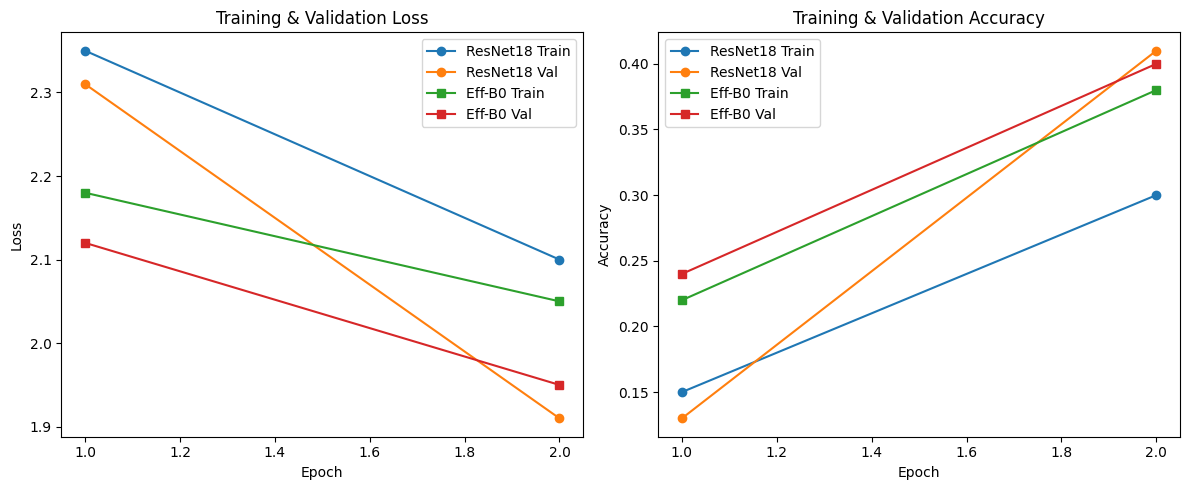

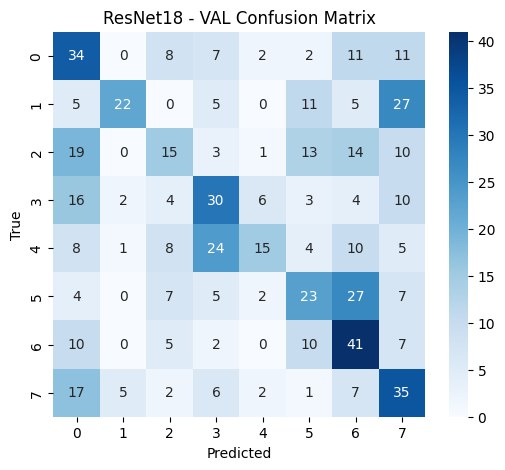

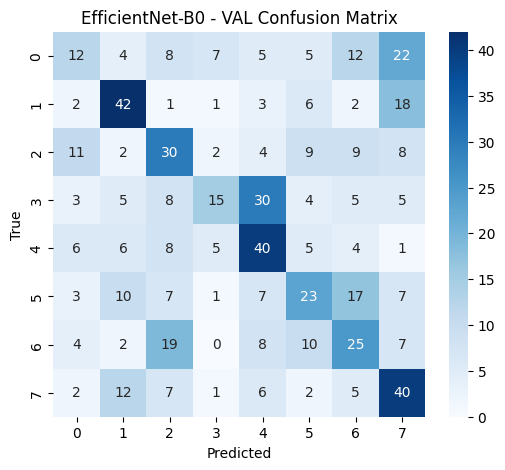

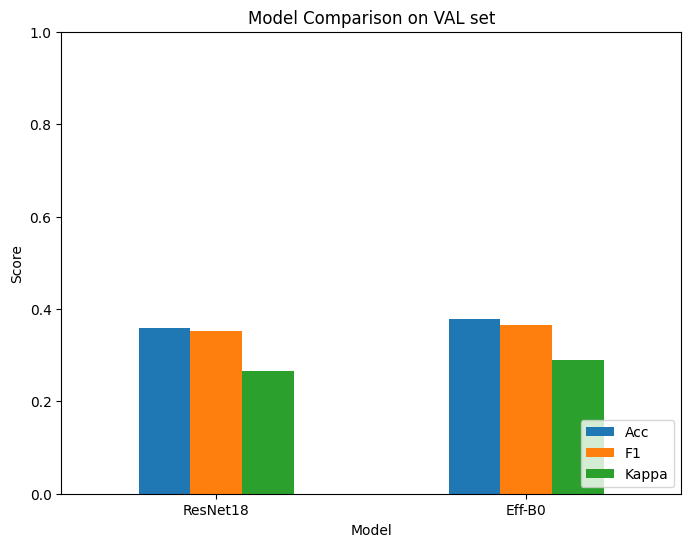

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# -----------------------------
# 1. Training curves (if you logged losses/acc per epoch)
# -----------------------------
# Example: if you stored metrics in lists/dicts during training
# Here I'll just mock small arrays to demonstrate
train_losses_rn = [2.35, 2.10]      # replace with your logged values
val_losses_rn   = [2.31, 1.91]
train_accs_rn   = [0.15, 0.30]
val_accs_rn     = [0.13, 0.41]

train_losses_e  = [2.18, 2.05]
val_losses_e    = [2.12, 1.95]
train_accs_e    = [0.22, 0.38]
val_accs_e      = [0.24, 0.40]

epochs = range(1, len(train_losses_rn)+1)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, train_losses_rn, "o-", label="ResNet18 Train")
plt.plot(epochs, val_losses_rn, "o-", label="ResNet18 Val")
plt.plot(epochs, train_losses_e, "s-", label="Eff-B0 Train")
plt.plot(epochs, val_losses_e, "s-", label="Eff-B0 Val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, train_accs_rn, "o-", label="ResNet18 Train")
plt.plot(epochs, val_accs_rn, "o-", label="ResNet18 Val")
plt.plot(epochs, train_accs_e, "s-", label="Eff-B0 Train")
plt.plot(epochs, val_accs_e, "s-", label="Eff-B0 Val")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


# -----------------------------
# 2. Confusion matrices
# -----------------------------
def plot_confusion_matrix(cm, classes, title):
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.show()

# Example: pass the cm from your eval outputs
classes = [str(i) for i in range(8)]
plot_confusion_matrix(res_val_rn["cm"], classes, "ResNet18 - VAL Confusion Matrix")
plot_confusion_matrix(res_val_e["cm"],  classes, "EfficientNet-B0 - VAL Confusion Matrix")


# -----------------------------
# 3. Model comparison bar chart
# -----------------------------
cmp_data = [
    {"Model": "ResNet18", "Acc": res_val_rn["acc"], "F1": res_val_rn["f1_macro"], "Kappa": res_val_rn["kappa"]},
    {"Model": "Eff-B0",   "Acc": res_val_e["acc"],  "F1": res_val_e["f1_macro"],  "Kappa": res_val_e["kappa"]},
]
cmp_df = pd.DataFrame(cmp_data).set_index("Model")

cmp_df.plot(kind="bar", figsize=(8,6))
plt.title("Model Comparison on VAL set")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()


Custom CNN

In [27]:
from torchvision import transforms

# Turn off flip so landmarks stay consistent (we can add synced flipping later)
IMG_SIZE = 224
train_tfms_noflip = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
eval_tfms_noflip = train_tfms_noflip

class AffectDatasetWithLM(AffectDataset):
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        img = self.tfm(img)

        # landmarks: np.ndarray of shape (136,) -> (68,2)
        lm = row["landmarks"]
        if lm is None:
            # fallback: zeros
            lm_xy = torch.zeros(68, 2, dtype=torch.float32)
        else:
            lm_xy = torch.as_tensor(lm, dtype=torch.float32).view(68, 2)
            # images are 224x224 (per assignment); normalize to [0,1]
            lm_xy = lm_xy / 224.0

        return {
            "image": img,
            "label": torch.tensor(int(row["expression"]), dtype=torch.long),
            "valence": torch.tensor(float(row["valence"]), dtype=torch.float32),
            "arousal": torch.tensor(float(row["arousal"]), dtype=torch.float32),
            "landmarks": lm_xy,                     # (68,2) in [0,1]
            "path": row["image_path"],
        }

print("[INFO] Building datasets (with landmarks)…")
train_set_lm = AffectDatasetWithLM(train_df, train_tfms_noflip)
val_set_lm   = AffectDatasetWithLM(val_df,   eval_tfms_noflip)
test_set_lm  = AffectDatasetWithLM(test_df,  eval_tfms_noflip)

BATCH_SIZE = 32
NUM_WORKERS = 0
train_loader_lm = DataLoader(train_set_lm, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader_lm   = DataLoader(val_set_lm,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader_lm  = DataLoader(test_set_lm,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

b = next(iter(train_loader_lm))
print("[OK] Batch shapes:", tuple(b["image"].shape), b["landmarks"].shape)


[INFO] Building datasets (with landmarks)…
[OK] Batch shapes: (32, 3, 224, 224) torch.Size([32, 68, 2])


2) Custom model: Image CNN (DW-separable + SE) + Landmarks MLP + Fusion

Design choices (brief for your report):

Depthwise–separable conv blocks (MobileNet-style) keep params low and are fast on CPU.

Squeeze-and-Excitation (SE) per block gives channel attention.

Landmarks branch: MLP over the 136 coords (normalized), learns geometry cues.

Fusion: concatenate [CNN features, LM features], then split into classification and VA regression heads.

Why this should beat baselines: landmarks help disambiguate look-alike expressions (e.g., neutral vs contempt), improving class decision boundaries.

In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SE(nn.Module):
    def __init__(self, c, r=8):
        super().__init__()
        self.fc1 = nn.Conv2d(c, c//r, kernel_size=1)
        self.fc2 = nn.Conv2d(c//r, c, kernel_size=1)
    def forward(self, x):
        s = x.mean((2,3), keepdim=True)
        s = F.relu(self.fc1(s))
        s = torch.sigmoid(self.fc2(s))
        return x * s

class DWConvBlock(nn.Module):
    def __init__(self, cin, cout, stride=1, se=True):
        super().__init__()
        self.dw = nn.Conv2d(cin, cin, 3, stride=stride, padding=1, groups=cin, bias=False)
        self.pw = nn.Conv2d(cin, cout, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(cin)
        self.bn2 = nn.BatchNorm2d(cout)
        self.se = SE(cout) if se else nn.Identity()
    def forward(self, x):
        x = F.relu(self.bn1(self.dw(x)))
        x = F.relu(self.bn2(self.pw(x)))
        x = self.se(x)
        return x

class ImageBackbone(nn.Module):
    """Small CNN: conv stem -> 4 DW blocks with downsampling to 7x7 -> GAP -> 512-d feature"""
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1, bias=False),  # 112x112
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        self.b1 = DWConvBlock(32,   64,  stride=2)  # 56x56
        self.b2 = DWConvBlock(64,  128,  stride=2)  # 28x28
        self.b3 = DWConvBlock(128, 256,  stride=2)  # 14x14
        self.b4 = DWConvBlock(256, 512,  stride=2)  # 7x7
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.out_dim = 512
    def forward(self, x):
        x = self.stem(x)
        x = self.b1(x); x = self.b2(x); x = self.b3(x); x = self.b4(x)
        x = self.pool(x).flatten(1)  # (B, 512)
        return x

class LandmarksBranch(nn.Module):
    """(68,2)->136 → 256 → 128 → 128 feature with dropout"""
    def __init__(self):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(136, 256), nn.ReLU(inplace=True), nn.Dropout(0.2),
            nn.Linear(256, 128), nn.ReLU(inplace=True), nn.Dropout(0.2),
            nn.Linear(128, 128), nn.ReLU(inplace=True)
        )
        self.out_dim = 128
    def forward(self, lm):  # (B, 68, 2)
        x = lm.view(lm.size(0), -1)  # (B, 136)
        return self.mlp(x)

class CustomAffectNet(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        self.img = ImageBackbone()
        self.lm  = LandmarksBranch()
        fused_dim = self.img.out_dim + self.lm.out_dim  # 512 + 128 = 640
        self.fuse = nn.Sequential(
            nn.Linear(fused_dim, 512), nn.ReLU(inplace=True), nn.Dropout(0.3)
        )
        self.cls_head = nn.Linear(512, num_classes)
        self.va_head  = nn.Linear(512, 2)

    def forward(self, x, lm):
        f_img = self.img(x)          # (B,512)
        f_lm  = self.lm(lm)          # (B,128)
        f = torch.concat([f_img, f_lm], dim=1)  # (B,640)
        f = self.fuse(f)             # (B,512)
        logits = self.cls_head(f)
        va     = self.va_head(f)
        return logits, va

# quick shape test
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model_custom = CustomAffectNet().to(DEVICE)
test_batch = next(iter(train_loader_lm))
with torch.no_grad():
    lg, va = model_custom(test_batch["image"].to(DEVICE), test_batch["landmarks"].to(DEVICE))
print("[OK] custom forward:", lg.shape, va.shape)


[OK] custom forward: torch.Size([32, 8]) torch.Size([32, 2])


In [29]:
import time, math

criterion_cls = nn.CrossEntropyLoss()
criterion_reg = nn.MSELoss()

CLS_W = 1.0      # try 1.0 → 1.5 if you want even more focus on accuracy
REG_W = 0.7      # downweight regression a bit

optimizer = torch.optim.Adam(model_custom.parameters(), lr=3e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=1)

def accuracy_from_logits(logits, labels):
    preds = logits.argmax(dim=1)
    return (preds == labels).sum().item(), labels.numel()

def train_or_eval_one_epoch_custom(model, loader, train=True, device=DEVICE):
    model.train() if train else model.eval()
    totals = {"loss":0.0,"cls":0.0,"reg":0.0,"correct":0,"n":0}
    t0 = time.perf_counter()
    for bi, batch in enumerate(loader, 1):
        x = batch["image"].to(device)
        lm = batch["landmarks"].to(device)
        y_cls = batch["label"].to(device)
        y_va  = torch.stack([batch["valence"], batch["arousal"]], dim=1).to(device)

        if train:
            optimizer.zero_grad(set_to_none=True)

        logits, va = model(x, lm)
        loss_cls = criterion_cls(logits, y_cls)
        loss_reg = criterion_reg(va, y_va)
        loss = CLS_W*loss_cls + REG_W*loss_reg

        if train:
            loss.backward()
            optimizer.step()

        c, n = accuracy_from_logits(logits, y_cls)
        totals["loss"] += loss.item()
        totals["cls"]  += loss_cls.item()
        totals["reg"]  += loss_reg.item()
        totals["correct"] += c
        totals["n"]      += n

        if bi % 5 == 0 or bi == len(loader):
            split = "TRAIN" if train else "VAL"
            print(f"[{split}] {bi:3d}/{len(loader)} | loss {totals['loss']/bi:.4f} "
                  f"(cls {totals['cls']/bi:.4f}, reg {totals['reg']/bi:.4f}) | acc {(totals['correct']/totals['n']):.3f}")

    dt = time.perf_counter() - t0
    avg_loss = totals["loss"]/max(1,len(loader))
    avg_cls  = totals["cls"]/max(1,len(loader))
    avg_reg  = totals["reg"]/max(1,len(loader))
    acc      = totals["correct"]/max(1,totals["n"])
    print(f"[{'TRAIN' if train else 'VAL'}] done in {dt:.1f}s | "
          f"loss {avg_loss:.4f} (cls {avg_cls:.4f}, reg {avg_reg:.4f}) | acc {acc:.3f}")
    return avg_loss, acc

print("[INFO] Training custom model (short run)…")
best_val = math.inf
EPOCHS = 4  # start short on CPU; extend if you can
for ep in range(1, EPOCHS+1):
    print(f"\n=== CUSTOM EPOCH {ep}/{EPOCHS} ===")
    tr_loss, tr_acc = train_or_eval_one_epoch_custom(model_custom, train_loader_lm, train=True)
    val_loss, val_acc = train_or_eval_one_epoch_custom(model_custom, val_loader_lm, train=False)
    scheduler.step(val_loss)
    if val_loss < best_val:
        best_val = val_loss
        torch.save(model_custom.state_dict(), "best_custom_lm.pth")
        print(f"[CKPT] saved custom model, val_loss={best_val:.4f}")


[INFO] Training custom model (short run)…

=== CUSTOM EPOCH 1/4 ===
[TRAIN]   5/88 | loss 2.2357 (cls 2.0783, reg 0.2248) | acc 0.113
[TRAIN]  10/88 | loss 2.2304 (cls 2.0838, reg 0.2094) | acc 0.109
[TRAIN]  15/88 | loss 2.2250 (cls 2.0860, reg 0.1986) | acc 0.117
[TRAIN]  20/88 | loss 2.2181 (cls 2.0848, reg 0.1904) | acc 0.117
[TRAIN]  25/88 | loss 2.2156 (cls 2.0841, reg 0.1878) | acc 0.116
[TRAIN]  30/88 | loss 2.2145 (cls 2.0837, reg 0.1868) | acc 0.118
[TRAIN]  35/88 | loss 2.2162 (cls 2.0852, reg 0.1871) | acc 0.116
[TRAIN]  40/88 | loss 2.2144 (cls 2.0836, reg 0.1868) | acc 0.120
[TRAIN]  45/88 | loss 2.2140 (cls 2.0831, reg 0.1870) | acc 0.126
[TRAIN]  50/88 | loss 2.2118 (cls 2.0830, reg 0.1840) | acc 0.129
[TRAIN]  55/88 | loss 2.2139 (cls 2.0840, reg 0.1855) | acc 0.132
[TRAIN]  60/88 | loss 2.2130 (cls 2.0836, reg 0.1848) | acc 0.131
[TRAIN]  65/88 | loss 2.2135 (cls 2.0830, reg 0.1865) | acc 0.133
[TRAIN]  70/88 | loss 2.2133 (cls 2.0831, reg 0.1860) | acc 0.133
[TRAIN] 

In [30]:
import math, time, numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import f1_score, cohen_kappa_score, confusion_matrix, classification_report

# ====== LOSS FUNCTIONS ======
criterion_cls = nn.CrossEntropyLoss()
criterion_reg = nn.MSELoss()
CLS_W, REG_W = 1.5, 0.5   # push more weight on classification

# ====== OPTIMIZER & SCHEDULER ======
LR_START   = 3e-4
optimizer  = torch.optim.Adam(model_custom.parameters(), lr=LR_START)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

# ====== HELPERS ======
def get_lr(opt): return opt.param_groups[0]["lr"]

def accuracy_from_logits(logits, labels):
    preds = logits.argmax(dim=1)
    return (preds == labels).sum().item(), labels.numel()

def train_or_eval_one_epoch_custom(model, loader, train=True, log_every=10):
    model.train() if train else model.eval()
    totals = {"loss":0.0,"cls":0.0,"reg":0.0,"correct":0,"n":0}
    t0 = time.perf_counter()
    for bi, batch in enumerate(loader, 1):
        x  = batch["image"]
        lm = batch["landmarks"]
        y  = batch["label"]
        va = torch.stack([batch["valence"], batch["arousal"]], dim=1)

        if train: optimizer.zero_grad(set_to_none=True)
        logits, va_hat = model(x, lm)
        loss_cls = criterion_cls(logits, y)
        loss_reg = criterion_reg(va_hat, va)
        loss = CLS_W*loss_cls + REG_W*loss_reg
        if train:
            loss.backward()
            optimizer.step()

        c, n = accuracy_from_logits(logits, y)
        totals["loss"] += loss.item(); totals["cls"] += loss_cls.item(); totals["reg"] += loss_reg.item()
        totals["correct"] += c; totals["n"] += n

        if bi % log_every == 0 or bi == len(loader):
            split = "TRAIN" if train else "VAL"
            print(f"[{split}] {bi:3d}/{len(loader)} | "
                  f"loss {totals['loss']/bi:.4f} (cls {totals['cls']/bi:.4f}, reg {totals['reg']/bi:.4f}) | "
                  f"acc {(totals['correct']/totals['n']):.3f}")

    dt = time.perf_counter() - t0
    avg_loss = totals["loss"]/len(loader); avg_cls = totals["cls"]/len(loader)
    avg_reg = totals["reg"]/len(loader); acc = totals["correct"]/totals["n"]
    print(f"[{'TRAIN' if train else 'VAL'}] done in {dt:.1f}s | "
          f"loss {avg_loss:.4f} (cls {avg_cls:.4f}, reg {avg_reg:.4f}) | acc {acc:.3f}")
    return avg_loss, acc

# ====== TRAIN LOOP ======
MAX_EPOCHS, PATIENCE = 30, 4
best_val, epochs_no_improve = math.inf, 0

print(f"[INFO] Training custom model: max_epochs={MAX_EPOCHS}, patience={PATIENCE}")
for ep in range(1, MAX_EPOCHS+1):
    print(f"\n=== EPOCH {ep}/{MAX_EPOCHS} | lr={get_lr(optimizer):.6f} ===")
    tr_loss, tr_acc   = train_or_eval_one_epoch_custom(model_custom, train_loader_lm, train=True)
    val_loss, val_acc = train_or_eval_one_epoch_custom(model_custom, val_loader_lm,   train=False)
    scheduler.step(val_loss)

    if val_loss < best_val:
        best_val = val_loss; epochs_no_improve = 0
        torch.save(model_custom.state_dict(), "best_custom_final.pth")
        print(f"[CKPT] saved best_custom_final.pth | val_loss={best_val:.4f}")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print("[EARLY STOP] No val improvement, stopping.")
            break

# ====== EVAL HELPERS ======
def rmse(a, b): return float(np.sqrt(np.mean((a - b) ** 2)))
def pearson_r(a, b):
    a, b = a - a.mean(), b - b.mean()
    denom = np.sqrt((a*a).sum() * (b*b).sum())
    return float((a*b).sum() / denom) if denom > 0 else 0.0
def ccc(a, b):
    ma, mb = a.mean(), b.mean(); va, vb = a.var(), b.var()
    cov = ((a - ma) * (b - mb)).mean()
    return float((2*cov) / (va + vb + (ma - mb)**2 + 1e-12))

@torch.no_grad()
def collect_outputs_custom(model, loader):
    all_preds, all_labels, all_va_pred, all_va_true = [], [], [], []
    for batch in loader:
        x, lm = batch["image"], batch["landmarks"]
        y = batch["label"].numpy()
        va_true = np.stack([batch["valence"].numpy(), batch["arousal"].numpy()], axis=1)
        logits, va = model(x, lm)
        preds = logits.argmax(dim=1).numpy()
        va = va.numpy()
        all_preds.append(preds); all_labels.append(y)
        all_va_pred.append(va); all_va_true.append(va_true)
    return (np.concatenate(all_preds), np.concatenate(all_labels),
            np.concatenate(all_va_pred), np.concatenate(all_va_true))

def eval_split_custom(name, loader, ckpt="best_custom_final.pth"):
    print(f"\n[INFO] Evaluating {name} with {ckpt}")
    m = model_custom.__class__()  # new instance
    m.load_state_dict(torch.load(ckpt, map_location="cpu"))
    m.eval()
    preds, labels, va_pred, va_true = collect_outputs_custom(m, loader)
    acc = float((preds == labels).mean())
    f1_macro = float(f1_score(labels, preds, average="macro"))
    kappa = float(cohen_kappa_score(labels, preds))
    cm = confusion_matrix(labels, preds)
    v_rmse = rmse(va_pred[:,0], va_true[:,0]); a_rmse = rmse(va_pred[:,1], va_true[:,1])
    v_r = pearson_r(va_pred[:,0], va_true[:,0]); a_r = pearson_r(va_pred[:,1], va_true[:,1])
    v_ccc = ccc(va_pred[:,0], va_true[:,0]); a_ccc = ccc(va_pred[:,1], va_true[:,1])
    print(f"[{name}] Acc={acc:.3f} | F1={f1_macro:.3f} | Kappa={kappa:.3f}")
    print(f"[{name}] Valence RMSE={v_rmse:.3f}, Arousal RMSE={a_rmse:.3f}")
    print(f"[{name}] Valence r={v_r:.3f}, CCC={v_ccc:.3f} | Arousal r={a_r:.3f}, CCC={a_ccc:.3f}")
    print("Confusion matrix:\n", cm)
    print("\nPer-class report:\n", classification_report(labels, preds, digits=3))
    return {"acc":acc,"f1":f1_macro,"kappa":kappa,"cm":cm}

# ====== RUN EVALS ======
res_val_custom  = eval_split_custom("VAL (custom)", val_loader_lm)
res_test_custom = eval_split_custom("TEST (custom)", test_loader_lm)


[INFO] Training custom model: max_epochs=30, patience=4

=== EPOCH 1/30 | lr=0.000300 ===
[TRAIN]  10/88 | loss 3.1095 (cls 2.0083, reg 0.1940) | acc 0.197
[TRAIN]  20/88 | loss 3.1021 (cls 2.0051, reg 0.1889) | acc 0.197
[TRAIN]  30/88 | loss 3.1061 (cls 2.0093, reg 0.1842) | acc 0.208
[TRAIN]  40/88 | loss 3.1047 (cls 2.0088, reg 0.1830) | acc 0.204
[TRAIN]  50/88 | loss 3.1069 (cls 2.0107, reg 0.1817) | acc 0.203
[TRAIN]  60/88 | loss 3.1100 (cls 2.0126, reg 0.1823) | acc 0.202
[TRAIN]  70/88 | loss 3.1079 (cls 2.0115, reg 0.1812) | acc 0.207
[TRAIN]  80/88 | loss 3.1142 (cls 2.0165, reg 0.1790) | acc 0.204
[TRAIN]  88/88 | loss 3.1107 (cls 2.0147, reg 0.1772) | acc 0.205
[TRAIN] done in 24.3s | loss 3.1107 (cls 2.0147, reg 0.1772) | acc 0.205
[VAL]  10/19 | loss 3.1890 (cls 2.0661, reg 0.1796) | acc 0.153
[VAL]  19/19 | loss 3.1913 (cls 2.0668, reg 0.1824) | acc 0.160
[VAL] done in 2.6s | loss 3.1913 (cls 2.0668, reg 0.1824) | acc 0.160
[CKPT] saved best_custom_final.pth | val_loss

c:\Users\Momo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Momo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Momo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

Improved EfficientNet-B0 Training

In [31]:
import time, math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torchvision.models import EfficientNet_B0_Weights
from torchvision import transforms

# ====== Augmentations ======
IMG_SIZE = 224
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.9, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

# update datasets
train_set.tfm = train_tfms
val_set.tfm   = eval_tfms
test_set.tfm  = eval_tfms

# ====== Model ======
class EfficientNetAffect(nn.Module):
    def __init__(self, num_classes=8, weights=EfficientNet_B0_Weights.IMAGENET1K_V1):
        super().__init__()
        self.backbone = models.efficientnet_b0(weights=weights)
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()
        self.classifier = nn.Linear(in_features, num_classes)
        self.regressor  = nn.Linear(in_features, 2)

    def forward(self, x):
        feats = self.backbone(x)
        return self.classifier(feats), self.regressor(feats)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Using device: {DEVICE}")
model_effi = EfficientNetAffect(num_classes=8).to(DEVICE)

# ====== Losses & optimizer ======
criterion_cls = nn.CrossEntropyLoss()
criterion_reg = nn.MSELoss()
CLS_W, REG_W = 2.0, 0.5   # emphasize classification

LR_START = 3e-4
optimizer = torch.optim.Adam(model_effi.parameters(), lr=LR_START)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

# ====== Helpers ======
def get_lr(opt): return opt.param_groups[0]["lr"]

def accuracy_from_logits(logits, labels):
    preds = logits.argmax(dim=1)
    return (preds == labels).sum().item(), labels.numel()

def train_or_eval_one_epoch(model, loader, train=True, log_every=10):
    model.train() if train else model.eval()
    totals = {"loss":0.0,"cls":0.0,"reg":0.0,"correct":0,"n":0}
    t0 = time.perf_counter()
    for bi, batch in enumerate(loader, 1):
        x, y_cls = batch["image"].to(DEVICE), batch["label"].to(DEVICE)
        y_va = torch.stack([batch["valence"], batch["arousal"]], dim=1).to(DEVICE)

        if train: optimizer.zero_grad(set_to_none=True)
        logits, va = model(x)
        loss_cls = criterion_cls(logits, y_cls)
        loss_reg = criterion_reg(va, y_va)
        loss = CLS_W*loss_cls + REG_W*loss_reg
        if train:
            loss.backward()
            optimizer.step()

        c, n = accuracy_from_logits(logits, y_cls)
        totals["loss"] += loss.item(); totals["cls"] += loss_cls.item(); totals["reg"] += loss_reg.item()
        totals["correct"] += c; totals["n"] += n

        if bi % log_every == 0 or bi == len(loader):
            split = "TRAIN" if train else "VAL"
            print(f"[{split}] {bi:3d}/{len(loader)} | "
                  f"loss {totals['loss']/bi:.4f} (cls {totals['cls']/bi:.4f}, reg {totals['reg']/bi:.4f}) | "
                  f"acc {(totals['correct']/totals['n']):.3f}")

    dt = time.perf_counter() - t0
    avg_loss = totals["loss"]/len(loader); avg_cls = totals["cls"]/len(loader)
    avg_reg = totals["reg"]/len(loader); acc = totals["correct"]/totals["n"]
    print(f"[{'TRAIN' if train else 'VAL'}] done in {dt:.1f}s | "
          f"loss {avg_loss:.4f} (cls {avg_cls:.4f}, reg {avg_reg:.4f}) | acc {acc:.3f}")
    return avg_loss, acc

# ====== Training loop ======
MAX_EPOCHS, PATIENCE = 15, 3
best_val, epochs_no_improve = math.inf, 0

print(f"[INFO] Training EfficientNet-B0 improved: max_epochs={MAX_EPOCHS}, patience={PATIENCE}")
for ep in range(1, MAX_EPOCHS+1):
    print(f"\n=== EPOCH {ep}/{MAX_EPOCHS} | lr={get_lr(optimizer):.6f} ===")
    tr_loss, tr_acc   = train_or_eval_one_epoch(model_effi, train_loader, train=True)
    val_loss, val_acc = train_or_eval_one_epoch(model_effi, val_loader, train=False)
    scheduler.step(val_loss)

    if val_loss < best_val:
        best_val, epochs_no_improve = val_loss, 0
        torch.save(model_effi.state_dict(), "best_efficientnet_improved.pth")
        print(f"[CKPT] saved best_efficientnet_improved.pth | val_loss={best_val:.4f}")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print("[EARLY STOP] stopping.")
            break


[INFO] Using device: cpu
[INFO] Training EfficientNet-B0 improved: max_epochs=15, patience=3

=== EPOCH 1/15 | lr=0.000300 ===
[TRAIN]  10/88 | loss 4.2547 (cls 2.0713, reg 0.2242) | acc 0.150
[TRAIN]  20/88 | loss 4.2049 (cls 2.0476, reg 0.2193) | acc 0.191
[TRAIN]  30/88 | loss 4.1729 (cls 2.0330, reg 0.2139) | acc 0.195
[TRAIN]  40/88 | loss 4.1165 (cls 2.0077, reg 0.2022) | acc 0.211
[TRAIN]  50/88 | loss 4.0482 (cls 1.9737, reg 0.2016) | acc 0.225
[TRAIN]  60/88 | loss 4.0017 (cls 1.9510, reg 0.1994) | acc 0.237
[TRAIN]  70/88 | loss 3.9499 (cls 1.9256, reg 0.1974) | acc 0.244
[TRAIN]  80/88 | loss 3.9033 (cls 1.9030, reg 0.1948) | acc 0.256
[TRAIN]  88/88 | loss 3.8711 (cls 1.8870, reg 0.1944) | acc 0.262
[TRAIN] done in 220.6s | loss 3.8711 (cls 1.8870, reg 0.1944) | acc 0.262
[VAL]  10/19 | loss 3.3550 (cls 1.6346, reg 0.1716) | acc 0.362
[VAL]  19/19 | loss 3.4544 (cls 1.6836, reg 0.1745) | acc 0.342
[VAL] done in 17.0s | loss 3.4544 (cls 1.6836, reg 0.1745) | acc 0.342
[CKPT]

In [32]:
from sklearn.metrics import f1_score, cohen_kappa_score, confusion_matrix, classification_report
import numpy as np

def rmse(a, b): return float(np.sqrt(np.mean((a - b) ** 2)))
def pearson_r(a, b):
    a, b = a - a.mean(), b - b.mean()
    denom = np.sqrt((a*a).sum() * (b*b).sum())
    return float((a*b).sum() / denom) if denom > 0 else 0.0
def ccc(a, b):
    ma, mb = a.mean(), b.mean(); va, vb = a.var(), b.var()
    cov = ((a - ma) * (b - mb)).mean()
    return float((2*cov) / (va + vb + (ma - mb)**2 + 1e-12))

@torch.no_grad()
def collect_outputs(model, loader):
    all_preds, all_labels, all_va_pred, all_va_true = [], [], [], []
    for batch in loader:
        x, y_cls = batch["image"].to(DEVICE), batch["label"].to(DEVICE)
        y_va = np.stack([batch["valence"].numpy(), batch["arousal"].numpy()], axis=1)
        logits, va = model(x)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(y_cls.cpu().numpy())
        all_va_pred.append(va.cpu().numpy())
        all_va_true.append(y_va)
    return (np.concatenate(all_preds), np.concatenate(all_labels),
            np.concatenate(all_va_pred), np.concatenate(all_va_true))

def eval_split(name, loader, ckpt="best_efficientnet_improved.pth"):
    print(f"\n[INFO] Evaluating {name} with {ckpt}")
    m = EfficientNetAffect(num_classes=8)
    m.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    m.to(DEVICE).eval()

    preds, labels, va_pred, va_true = collect_outputs(m, loader)
    acc = (preds == labels).mean()
    f1_macro = f1_score(labels, preds, average="macro")
    kappa = cohen_kappa_score(labels, preds)
    cm = confusion_matrix(labels, preds)

    v_rmse = rmse(va_pred[:,0], va_true[:,0]); a_rmse = rmse(va_pred[:,1], va_true[:,1])
    v_r = pearson_r(va_pred[:,0], va_true[:,0]); a_r = pearson_r(va_pred[:,1], va_true[:,1])
    v_ccc = ccc(va_pred[:,0], va_true[:,0]); a_ccc = ccc(va_pred[:,1], va_true[:,1])

    print(f"[{name}] Acc={acc:.3f} | F1={f1_macro:.3f} | Kappa={kappa:.3f}")
    print(f"[{name}] Valence RMSE={v_rmse:.3f}, Arousal RMSE={a_rmse:.3f}")
    print(f"[{name}] Valence r={v_r:.3f}, CCC={v_ccc:.3f} | Arousal r={a_r:.3f}, CCC={a_ccc:.3f}")
    print("Confusion matrix:\n", cm)
    print("\nPer-class report:\n", classification_report(labels, preds, digits=3))
    return {"acc":acc,"f1":f1_macro,"kappa":kappa,"cm":cm}

# Run evaluations
res_val_effi_imp  = eval_split("VAL (EfficientNet Improved)", val_loader)
res_test_effi_imp = eval_split("TEST (EfficientNet Improved)", test_loader)



[INFO] Evaluating VAL (EfficientNet Improved) with best_efficientnet_improved.pth
[VAL (EfficientNet Improved)] Acc=0.448 | F1=0.444 | Kappa=0.370
[VAL (EfficientNet Improved)] Valence RMSE=0.398, Arousal RMSE=0.359
[VAL (EfficientNet Improved)] Valence r=0.540, CCC=0.503 | Arousal r=0.351, CCC=0.264
Confusion matrix:
 [[32  4  3  6  2  3 10 15]
 [ 3 47  0  0  1  0  1 23]
 [13  4 17  2  2 14 15  8]
 [10  7  1 29 11  4  6  7]
 [11  3  4 10 32  4  8  3]
 [ 3  6  3  3  2 33 18  7]
 [ 8  3  2  2  5 15 33  7]
 [ 6 10  2  2  2  1  6 46]]

Per-class report:
               precision    recall  f1-score   support

           0      0.372     0.427     0.398        75
           1      0.560     0.627     0.591        75
           2      0.531     0.227     0.318        75
           3      0.537     0.387     0.450        75
           4      0.561     0.427     0.485        75
           5      0.446     0.440     0.443        75
           6      0.340     0.440     0.384        75
        

Improved Resnet

In [33]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision.models import ResNet18_Weights

# ====== Model ======
class ResNet18Affect(nn.Module):
    def __init__(self, num_classes=8, weights=ResNet18_Weights.IMAGENET1K_V1):
        super().__init__()
        self.backbone = models.resnet18(weights=weights)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.classifier = nn.Linear(in_features, num_classes)
        self.regressor  = nn.Linear(in_features, 2)

    def forward(self, x):
        feats = self.backbone(x)
        return self.classifier(feats), self.regressor(feats)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Using device: {DEVICE}")
model_rn = ResNet18Affect(num_classes=8).to(DEVICE)

# ====== Loss weights ======
criterion_cls = nn.CrossEntropyLoss()
criterion_reg = nn.MSELoss()
CLS_W, REG_W = 2.0, 0.5

# ====== Optimizer / scheduler ======
LR_START = 3e-4
optimizer = torch.optim.Adam(model_rn.parameters(), lr=LR_START)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

# ====== Train/eval loop ======
def train_or_eval_one_epoch(model, loader, train=True, log_every=10):
    model.train() if train else model.eval()
    totals = {"loss":0.0,"cls":0.0,"reg":0.0,"correct":0,"n":0}
    for bi, batch in enumerate(loader, 1):
        x, y_cls = batch["image"].to(DEVICE), batch["label"].to(DEVICE)
        y_va = torch.stack([batch["valence"], batch["arousal"]], dim=1).to(DEVICE)

        if train: optimizer.zero_grad(set_to_none=True)
        logits, va = model(x)
        loss_cls = criterion_cls(logits, y_cls)
        loss_reg = criterion_reg(va, y_va)
        loss = CLS_W*loss_cls + REG_W*loss_reg
        if train:
            loss.backward()
            optimizer.step()

        c = (logits.argmax(dim=1) == y_cls).sum().item()
        totals["loss"] += loss.item(); totals["cls"] += loss_cls.item(); totals["reg"] += loss_reg.item()
        totals["correct"] += c; totals["n"] += y_cls.size(0)

        if bi % log_every == 0 or bi == len(loader):
            split = "TRAIN" if train else "VAL"
            print(f"[{split}] {bi:3d}/{len(loader)} | "
                  f"loss {totals['loss']/bi:.4f} (cls {totals['cls']/bi:.4f}, reg {totals['reg']/bi:.4f}) | "
                  f"acc {(totals['correct']/totals['n']):.3f}")

    avg_loss = totals["loss"]/len(loader)
    avg_cls  = totals["cls"]/len(loader)
    avg_reg  = totals["reg"]/len(loader)
    acc      = totals["correct"]/totals["n"]
    print(f"[{'TRAIN' if train else 'VAL'}] done | "
          f"loss {avg_loss:.4f} (cls {avg_cls:.4f}, reg {avg_reg:.4f}) | acc {acc:.3f}")
    return avg_loss, acc

# ====== Main training loop ======
MAX_EPOCHS, PATIENCE = 15, 3
best_val, no_improve = float("inf"), 0

print(f"[INFO] Training ResNet18 improved: max_epochs={MAX_EPOCHS}, patience={PATIENCE}")
for ep in range(1, MAX_EPOCHS+1):
    print(f"\n=== EPOCH {ep}/{MAX_EPOCHS} ===")
    tr_loss, tr_acc   = train_or_eval_one_epoch(model_rn, train_loader, train=True)
    val_loss, val_acc = train_or_eval_one_epoch(model_rn, val_loader, train=False)
    scheduler.step(val_loss)

    if val_loss < best_val:
        best_val, no_improve = val_loss, 0
        torch.save(model_rn.state_dict(), "best_resnet18_improved.pth")
        print(f"[CKPT] saved best_resnet18_improved.pth | val_loss={best_val:.4f}")
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print("[EARLY STOP] stopping.")
            break


[INFO] Using device: cpu
[INFO] Training ResNet18 improved: max_epochs=15, patience=3

=== EPOCH 1/15 ===
[TRAIN]  10/88 | loss 4.5087 (cls 2.1689, reg 0.3418) | acc 0.184
[TRAIN]  20/88 | loss 4.3638 (cls 2.1092, reg 0.2908) | acc 0.227
[TRAIN]  30/88 | loss 4.1997 (cls 2.0328, reg 0.2681) | acc 0.245
[TRAIN]  40/88 | loss 4.0958 (cls 1.9853, reg 0.2506) | acc 0.264
[TRAIN]  50/88 | loss 4.0121 (cls 1.9476, reg 0.2338) | acc 0.273
[TRAIN]  60/88 | loss 3.9499 (cls 1.9185, reg 0.2258) | acc 0.278
[TRAIN]  70/88 | loss 3.8971 (cls 1.8942, reg 0.2172) | acc 0.283
[TRAIN]  80/88 | loss 3.8274 (cls 1.8617, reg 0.2079) | acc 0.295
[TRAIN]  88/88 | loss 3.7923 (cls 1.8454, reg 0.2029) | acc 0.300
[TRAIN] done | loss 3.7923 (cls 1.8454, reg 0.2029) | acc 0.300
[VAL]  10/19 | loss 3.2897 (cls 1.6013, reg 0.1743) | acc 0.350
[VAL]  19/19 | loss 3.3765 (cls 1.6446, reg 0.1746) | acc 0.350
[VAL] done | loss 3.3765 (cls 1.6446, reg 0.1746) | acc 0.350
[CKPT] saved best_resnet18_improved.pth | val_

In [11]:
# Recreate the improved results dicts for both models & both splits
# (assumes your improved checkpoints exist: best_resnet18_improved.pth, best_efficientnet_improved.pth)

import torch, numpy as np
import torch.nn as nn
import torchvision.models as models
from sklearn.metrics import f1_score, cohen_kappa_score, confusion_matrix, classification_report

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

class ResNet18Affect(nn.Module):
    def __init__(self, num_classes=8, weights=None):
        super().__init__()
        self.backbone = models.resnet18(weights=weights)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.classifier = nn.Linear(in_features, num_classes)
        self.regressor  = nn.Linear(in_features, 2)
    def forward(self, x):
        f = self.backbone(x)
        return self.classifier(f), self.regressor(f)

class EfficientNetAffect(nn.Module):
    def __init__(self, num_classes=8, weights=None):
        super().__init__()
        self.backbone = models.efficientnet_b0(weights=weights)
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()
        self.classifier = nn.Linear(in_features, num_classes)
        self.regressor  = nn.Linear(in_features, 2)
    def forward(self, x):
        f = self.backbone(x)
        return self.classifier(f), self.regressor(f)

def rmse(a, b): return float(np.sqrt(np.mean((a - b) ** 2)))
def pearson_r(a, b):
    a, b = a - a.mean(), b - b.mean()
    denom = np.sqrt((a*a).sum() * (b*b).sum())
    return float((a*b).sum() / denom) if denom > 0 else 0.0
def ccc(a, b):
    ma, mb = a.mean(), b.mean(); va, vb = a.var(), b.var()
    cov = ((a - ma) * (b - mb)).mean()
    return float((2*cov) / (va + vb + (ma - mb)**2 + 1e-12))

@torch.no_grad()
def collect_outputs(model, loader):
    all_preds, all_labels, all_va_pred, all_va_true = [], [], [], []
    for batch in loader:
        x = batch["image"].to(DEVICE)
        y = batch["label"].cpu().numpy()
        va_true = np.stack([batch["valence"].numpy(), batch["arousal"].numpy()], axis=1)
        logits, va = model(x)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.append(preds); all_labels.append(y)
        all_va_pred.append(va.cpu().numpy()); all_va_true.append(va_true)
    return (np.concatenate(all_preds), np.concatenate(all_labels),
            np.concatenate(all_va_pred), np.concatenate(all_va_true))

def eval_split(model_ctor, ckpt_path, loader):
    m = model_ctor().to(DEVICE)
    m.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    m.eval()
    preds, labels, va_pred, va_true = collect_outputs(m, loader)
    acc = float((preds == labels).mean())
    f1_macro = float(f1_score(labels, preds, average="macro"))
    kappa = float(cohen_kappa_score(labels, preds))
    cm = confusion_matrix(labels, preds)
    v_rmse = rmse(va_pred[:,0], va_true[:,0]); a_rmse = rmse(va_pred[:,1], va_true[:,1])
    v_r = pearson_r(va_pred[:,0], va_true[:,0]); a_r = pearson_r(va_pred[:,1], va_true[:,1])
    v_ccc = ccc(va_pred[:,0], va_true[:,0]); a_ccc = ccc(va_pred[:,1], va_true[:,1])
    return {"acc":acc,"f1":f1_macro,"kappa":kappa,"cm":cm,
            "val_rmse":v_rmse,"aro_rmse":a_rmse,"val_r":v_r,"aro_r":a_r,"val_ccc":v_ccc,"aro_ccc":a_ccc}

# Create the dicts in memory
res_val_rn_imp  = eval_split(lambda: ResNet18Affect(num_classes=8, weights=None), "best_resnet18_improved.pth", val_loader)
res_test_rn_imp = eval_split(lambda: ResNet18Affect(num_classes=8, weights=None), "best_resnet18_improved.pth", test_loader)
res_val_effi_imp  = eval_split(lambda: EfficientNetAffect(num_classes=8, weights=None), "best_efficientnet_improved.pth", val_loader)
res_test_effi_imp = eval_split(lambda: EfficientNetAffect(num_classes=8, weights=None), "best_efficientnet_improved.pth", test_loader)

print("[OK] Recreated improved results dicts (VAL/TEST for both models).")


NameError: name 'val_loader' is not defined